# Simulation ODE / DAE

Compared to [NLE Simulations](<../Simulation NLE>) an additional concept is introduced: `VariableState`.
This class of variables represents differentiable variables. For each variable there should be an equation, the order of equations is strictly related to the order in which state variables are added to the variable list.
Yeast growth model [1] is taken as an example of a dynamic model. OED models are formulated in the same way as DAE models, without the use of algebraic variables.
$$\dot{x_1} = (r - u_1 - \theta_4)x_1$$
$$\dot{x_2} = -\frac{rx_1}{\theta_3} + u_1 (u_2 - x_2)$$
$$0 = r - \frac{\theta_1 x_2}{\theta_2 + x_2}$$


[1] Asprey, S., Macchietto, S., 2002. Designing robust optimal dynamic experiments. Journal of Process Control 12, 545–556. doi:10.1016/s0959-1524(01)00020-8.
## Model creation

In [25]:
import mopeds
import numpy as np
import matplotlib.pyplot as plt

variable_list = mopeds.variables.VariableList()

variable_list.add_variable(mopeds.VariableState("x1", 5, 0, 10))
variable_list.add_variable(mopeds.VariableState("x2", 0.01))
variable_list.add_variable(mopeds.VariableAlgebraic("r", 1.7))
variable_list.add_variable(mopeds.VariableControl("u1", 0.125, 0.05, 0.2))
variable_list.add_variable(mopeds.VariableControl("u2", 35, 5, 35))

variable_list.add_variable(mopeds.VariableParameter("theta1", 0.310, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta2", 0.180, 1e-2, 20))
variable_list.add_variable(mopeds.VariableParameter("theta3", 0.550, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta4", 0.050, 1e-2, 2))

m = mopeds.Model(variable_list)

x1 = m.varlist_all["x1"].casadi_var
x2 = m.varlist_all["x2"].casadi_var
r = m.varlist_all["r"].casadi_var
u1 = m.varlist_all["u1"].casadi_var
u2 = m.varlist_all["u2"].casadi_var

theta1 = m.varlist_all["theta1"].casadi_var
theta2 = m.varlist_all["theta2"].casadi_var
theta3 = m.varlist_all["theta3"].casadi_var
theta4 = m.varlist_all["theta4"].casadi_var

eq_alg1 = r - (theta1 * x2 / (theta2 + x2))

eq1 = (r - u1 - theta4)  * x1
eq2 = - (r * x1 / theta3) + u1 * (u2 - x2)

m.add_equations_differential([eq1, eq2])
m.add_equations_algebraic([eq_alg1])

State variables are initialized with values, which are used at time zero.

## Simulation

To solve the system, similar API is used. Additionally to model and variable list, one needs to supply time grid, which has to start with 0.
Use `.simulate()` to have easier time plotting and analyzing results.

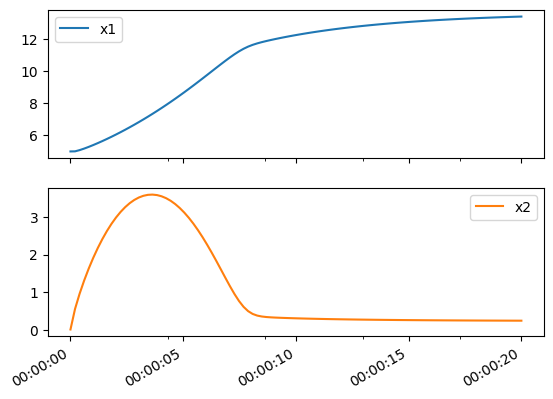

In [26]:
time_grid = np.linspace(0,20,100)
sim = mopeds.Simulator(m, time_grid, variable_list)
res_sim = sim.simulate(algebraic=True)[2]
res_sim.plot(show=False)
plt.show()

Each variable has attribute `.ignore_plotting` which can be used to control which variables of a variable list will be plotted.

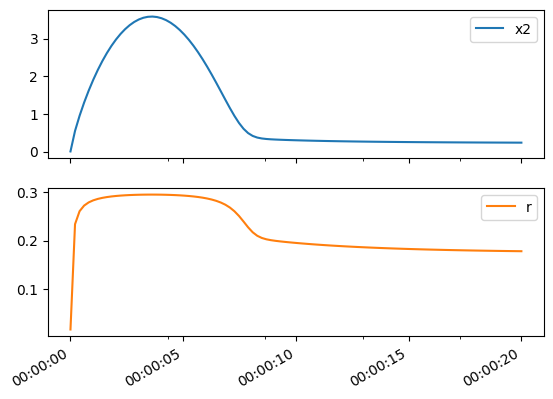

In [27]:
res_sim["r"].ignore_plotting = False
res_sim["x1"].ignore_plotting = True

res_sim.plot(show=False, algebraic=True)
plt.show()

Dataframe of returned variable list has all the information about the simulation.
Initial value of the simulation can be changed via a variable list.

x1 values [10.0, 12.461813979143642, 13.290507592021774, 13.54479786055919]
x1 simulation time [0.0, 6.666666666, 13.333333333, 20.0]


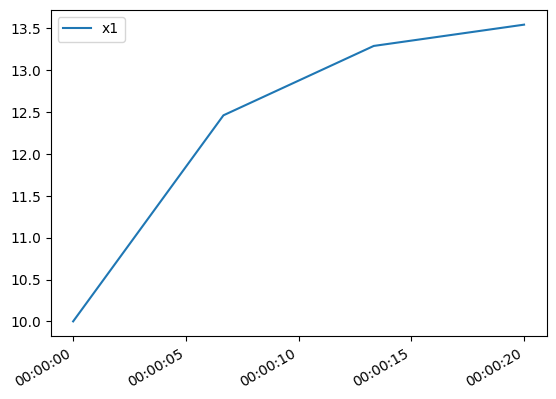

,x1
1970-01-01 00:00:00.000000000,10.000000
1970-01-01 00:00:06.666666666,12.461814
1970-01-01 00:00:13.333333333,13.290508
1970-01-01 00:00:20.000000000,13.544798


In [28]:
time_grid = np.linspace(0,20,4)
variable_list["x1"].value = 10
sim = mopeds.Simulator(m, time_grid, variable_list)
res_sim = sim.simulate(algebraic=True)[2]
print("x1 values", res_sim["x1"].value)
print("x1 simulation time", res_sim["x1"].time_relative)
res_sim["x1"].plot()
res_sim["x1"].dataframe

## Consistent variable values

Same as with NLE models, simulation convergence depends on good guesses of algebraic variables and consistent initial conditions.

If we set `x2` value to `-theta2` algebraic equations cannot be solved at time 0, and user gets an error.

In [29]:
variable_list["x2"].value = - 0.180
sim = mopeds.Simulator(m, time_grid, variable_list)
try:
    res_sim = sim.simulate(algebraic=True)[2]
except Exception as e:
    print(e)

Error in Function::call for 'integrator_tau' [IdasInterface] at .../casadi/core/function.cpp:1401:
Error in Function::call for 'integrator_tau' [IdasInterface] at .../casadi/core/function.cpp:330:
.../casadi/interfaces/sundials/idas_interface.cpp:596: IDASolve returned "IDA_CONV_FAIL". Consult IDAS documentation.


At t = 0 and h = 1.1392e-13, the corrector convergence failed repeatedly or with |h| = hmin.


## Piecewise constant control

Additional class of variables exist, to represent change of the control over time. Model below looks the same as above, only time of `u2` variable is changed.

In [30]:
import mopeds
import numpy as np
import matplotlib.pyplot as plt

variable_list = mopeds.variables.VariableList()

variable_list.add_variable(mopeds.VariableState("x1", 5, 0, 10))
variable_list.add_variable(mopeds.VariableState("x2", 0.01))
variable_list.add_variable(mopeds.VariableAlgebraic("r", 1.7))
variable_list.add_variable(mopeds.VariableControl("u1", 0.125, 0.05, 0.2))
variable_list.add_variable(mopeds.VariableControlPiecewiseConstant("u2", 35, 5, 35))

variable_list.add_variable(mopeds.VariableParameter("theta1", 0.310, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta2", 0.180, 1e-2, 20))
variable_list.add_variable(mopeds.VariableParameter("theta3", 0.550, 1e-2, 2))
variable_list.add_variable(mopeds.VariableParameter("theta4", 0.050, 1e-2, 2))

m = mopeds.Model(variable_list)

x1 = m.varlist_all["x1"].casadi_var
x2 = m.varlist_all["x2"].casadi_var
r = m.varlist_all["r"].casadi_var
u1 = m.varlist_all["u1"].casadi_var
u2 = m.varlist_all["u2"].casadi_var

theta1 = m.varlist_all["theta1"].casadi_var
theta2 = m.varlist_all["theta2"].casadi_var
theta3 = m.varlist_all["theta3"].casadi_var
theta4 = m.varlist_all["theta4"].casadi_var

eq_alg1 = r - (theta1 * x2 / (theta2 + x2))

eq1 = (r - u1 - theta4)  * x1
eq2 = - (r * x1 / theta3) + u1 * (u2 - x2)

m.add_equations_differential([eq1, eq2])
m.add_equations_algebraic([eq_alg1])

One needs to specify control variable values and respective changing times. They do not have to be included in time grid of a simulator.

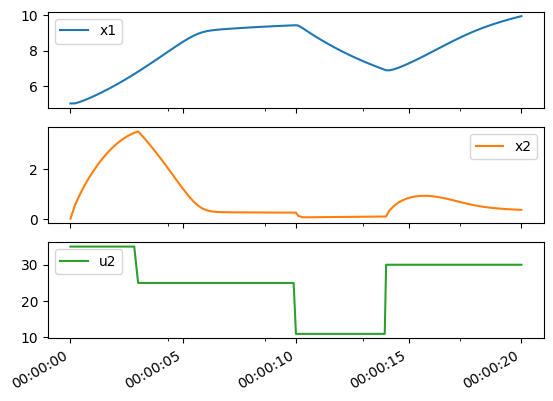

In [31]:
time_grid = np.linspace(0,20,100)
variable_list["u2"].ignore_plotting = False
variable_list["u2"].expand_horizon(times=[3,10,14], values=[25, 11, 30])
sim = mopeds.Simulator(m, time_grid, variable_list)
res_sim = sim.simulate(algebraic=True)[2]
res_sim.plot(show=False)
plt.show()